# Stage 1: LOS/NLOS Classifier Metrics Reference
## All 4 Encoders (LNN v3, LSTM, CNN, BERT) — Seen + Unseen Data

**Purpose**: Consolidated reference file for report writing. Contains full metrics for the LOS/NLOS binary classifier across all 4 encoder architectures.

**Metrics included per encoder:**
- Confusion Matrix
- Classification Report (Precision, Recall, F1-Score)
- ROC Curve + AUC
- Precision-Recall Curve + AP
- Per-scenario accuracy breakdown
- Prediction confidence distributions

**Evaluated on:**
1. **Seen (test split)** — 15% held-out from `combined_uwb_dataset.csv` (3 LOS + 3 NLOS scenarios)
2. **Unseen (OOD)** — `unseen_dataset.csv` (2 LOS + 2 NLOS scenarios never seen during training)

**Seen scenarios** (train): 8.41m/9.29m/9.76m LOS, 9.54m/16.09m/16.80m NLOS

**Unseen scenarios**: 4.55m/10.19m LOS, 8.91m/12.79m NLOS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import torch
import torch.nn as nn
import torch.nn.functional as F
import re
import os
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── CONFIG ──
CONFIG = {
    "search_start": 740,
    "search_end": 810,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "seed": 42,
}
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])

Device: cuda


---
## 1. Helper Functions (Data Loading + Preprocessing)

In [2]:
# ==========================================
# ROI ALIGNMENT + PREPROCESSING
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)
    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]
    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val
    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break
    return leading_edge


def preprocess_cir(sig, leading_edge, total_len, pre_crop):
    """Generic CIR preprocessing: crop window + min-max normalize."""
    start = max(0, leading_edge - pre_crop)
    end = start + total_len
    if end > len(sig):
        end = len(sig)
        start = max(0, end - total_len)
    crop = sig[start:end]
    if len(crop) < total_len:
        crop = np.pad(crop, (0, total_len - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(total_len)
    return crop


def load_dataset(filepath):
    """Load dataset and preprocess CIR signals."""
    df = pd.read_csv(filepath)
    cir_cols = sorted(
        [c for c in df.columns if re.match(r'^CIR_?\d+$', c)],
        key=lambda c: int(re.search(r'\d+', c).group())
    )
    print(f"Loaded {len(df)} rows from {filepath} ({len(cir_cols)} CIR columns)")

    raw_sigs, leading_edges = [], []
    labels, source_files = [], []

    for _, row in df.iterrows():
        sig = row[cir_cols].values.astype(float)
        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc
        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)
        labels.append(float(row["Label"]))
        source_files.append(row.get("Source_File", ""))

    return (np.array(raw_sigs), np.array(leading_edges),
            np.array(labels), np.array(source_files))


print("Helper functions loaded.")

Helper functions loaded.


---
## 2. Encoder Class Definitions

In [3]:
# ==========================================
# LNN ENCODER (DualCircuit_PI_HLNN_NoFP v3)
# ==========================================
class PILiquidCell(nn.Module):
    def __init__(self, input_size, hidden_size, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.ode_unfolds = ode_unfolds
        self.gleak = nn.Parameter(torch.empty(hidden_size).uniform_(0.001, 1.0))
        self.vleak = nn.Parameter(torch.empty(hidden_size).uniform_(-0.2, 0.2))
        self.cm    = nn.Parameter(torch.empty(hidden_size).uniform_(0.4, 0.6))
        self.w     = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.001, 1.0))
        self.erev  = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-0.2, 0.2))
        self.mu    = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.3, 0.8))
        self.sigma = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(3, 8))
        self.sensory_w     = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.001, 1.0))
        self.sensory_mu    = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.3, 0.8))
        self.sensory_sigma = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(3, 8))

    def forward(self, x_t, h_prev, dt=1.0):
        gleak = F.softplus(self.gleak)
        cm = F.softplus(self.cm)
        w = F.softplus(self.w)
        sensory_w = F.softplus(self.sensory_w)
        sensory_gate = torch.sigmoid(self.sensory_sigma * (x_t.unsqueeze(-1) - self.sensory_mu))
        sensory_current = (sensory_w * sensory_gate * x_t.unsqueeze(-1)).sum(dim=1)
        cm_t = cm / (dt / self.ode_unfolds)
        v = h_prev
        for _ in range(self.ode_unfolds):
            recurrent_gate = torch.sigmoid(self.sigma.unsqueeze(0) * (v.unsqueeze(2) - self.mu.unsqueeze(0)))
            w_gate = w.unsqueeze(0) * recurrent_gate
            w_num = (w_gate * self.erev.unsqueeze(0)).sum(dim=1)
            w_den = w_gate.sum(dim=1)
            numerator = cm_t * v + gleak * self.vleak + w_num + sensory_current
            denominator = cm_t + gleak + w_den + 1e-8
            v = numerator / denominator
            v = torch.clamp(v, -1.0, 1.0)
        tau = cm / (gleak + w_den + 1e-8)
        return v, tau


class DualCircuit_PI_HLNN_NoFP(nn.Module):
    """v3: No gate bias override, gating before cell forward."""
    def __init__(self, input_size=1, hidden_size=32, dropout=0.2, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell_los = PILiquidCell(input_size, hidden_size, ode_unfolds)
        self.cell_nlos = PILiquidCell(input_size, hidden_size, ode_unfolds)
        self.P_nlos2los = nn.Linear(hidden_size, hidden_size, bias=False)
        self.P_los2nlos = nn.Linear(hidden_size, hidden_size, bias=False)
        self.gate_los = nn.Linear(hidden_size * 2, hidden_size)
        self.gate_nlos = nn.Linear(hidden_size * 2, hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )

    def _run_circuits(self, x_seq):
        B, T, _ = x_seq.shape
        h_los = torch.zeros(B, self.hidden_size, device=x_seq.device)
        h_nlos = torch.zeros(B, self.hidden_size, device=x_seq.device)
        los_all, nlos_all = [], []
        tau_los_sum = torch.zeros_like(h_los)
        tau_nlos_sum = torch.zeros_like(h_nlos)
        tau_los_hist, tau_nlos_hist = [], []
        for t in range(T):
            x_t = x_seq[:, t, :]
            proj_nlos = self.P_nlos2los(h_nlos)
            proj_los = self.P_los2nlos(h_los)
            g_los = torch.sigmoid(self.gate_los(torch.cat([h_los, proj_nlos], dim=1)))
            g_nlos = torch.sigmoid(self.gate_nlos(torch.cat([h_nlos, proj_los], dim=1)))
            h_los_in = h_los + g_los * proj_nlos
            h_nlos_in = h_nlos + g_nlos * proj_los
            h_los, tau_los = self.cell_los(x_t, h_los_in)
            h_nlos, tau_nlos = self.cell_nlos(x_t, h_nlos_in)
            los_all.append(h_los.unsqueeze(1))
            nlos_all.append(h_nlos.unsqueeze(1))
            tau_los_sum += tau_los
            tau_nlos_sum += tau_nlos
            tau_los_hist.append(tau_los.unsqueeze(1))
            tau_nlos_hist.append(tau_nlos.unsqueeze(1))
        los_all = torch.cat(los_all, dim=1)
        nlos_all = torch.cat(nlos_all, dim=1)
        tau_los_mean = tau_los_sum / T
        tau_nlos_mean = tau_nlos_sum / T
        tau_los_hist = torch.cat(tau_los_hist, dim=1)
        tau_nlos_hist = torch.cat(tau_nlos_hist, dim=1)
        return los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean

    def _pool_and_fuse(self, los_all, nlos_all):
        return torch.cat([los_all.mean(dim=1), nlos_all.mean(dim=1)], dim=-1)

    def forward(self, x_seq, return_dynamics=False):
        los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean = self._run_circuits(x_seq)
        fused = self._pool_and_fuse(los_all, nlos_all)
        pred = self.classifier(fused)
        if return_dynamics:
            return pred, los_all, nlos_all, tau_los_hist, tau_nlos_hist, tau_los_mean, tau_nlos_mean
        return pred, tau_los_mean, tau_nlos_mean

    def embed(self, x_seq):
        los_all, nlos_all, *_ = self._run_circuits(x_seq)
        return self._pool_and_fuse(los_all, nlos_all)


print("LNN encoder defined (v3).")

LNN encoder defined (v3).


In [4]:
# ==========================================
# LSTM ENCODER
# ==========================================
class LSTM_Classifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x_seq, return_dynamics=False):
        B = x_seq.size(0)
        h0 = torch.zeros(1, B, self.hidden_size, device=x_seq.device)
        c0 = torch.zeros(1, B, self.hidden_size, device=x_seq.device)
        h_all, _ = self.lstm(x_seq, (h0, c0))
        h_avg = h_all.mean(dim=1)
        pred = self.classifier(h_avg)
        if return_dynamics:
            return pred, h_all
        return pred

    def embed(self, x_seq):
        B = x_seq.size(0)
        h0 = torch.zeros(1, B, self.hidden_size, device=x_seq.device)
        c0 = torch.zeros(1, B, self.hidden_size, device=x_seq.device)
        h_all, _ = self.lstm(x_seq, (h0, c0))
        return h_all.mean(dim=1)


print("LSTM encoder defined.")

LSTM encoder defined.


In [5]:
# ==========================================
# CNN ENCODER
# ==========================================
class CNN_Classifier(nn.Module):
    def __init__(self, input_channels=1, embedding_size=128, dropout=0.4):
        super().__init__()
        self.embedding_size = embedding_size
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2, stride=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 128, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 32), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(32, 1), nn.Sigmoid(),
        )

    def _encode_cir(self, x):
        features = self.encoder(x)
        return self.gap(features).squeeze(-1)

    def forward(self, x, return_dynamics=False):
        cnn_embed = self._encode_cir(x)
        pred = self.classifier(cnn_embed)
        if return_dynamics:
            return pred, self.encoder(x)
        return pred

    def embed(self, x):
        return self._encode_cir(x)


print("CNN encoder defined.")

CNN encoder defined.


In [6]:
# ==========================================
# BERT ENCODER
# ==========================================
class BERT_Classifier(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.2, max_seq_len=60):
        super().__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1), nn.Sigmoid()
        )

    def _encode(self, x_seq):
        x = self.input_proj(x_seq)
        x = x + self.pos_embed[:, :x.size(1), :]
        return self.transformer(x)

    def forward(self, x_seq, return_dynamics=False):
        h_all = self._encode(x_seq)
        h_avg = self.norm(h_all.mean(dim=1))
        pred = self.classifier(h_avg)
        if return_dynamics:
            return pred, h_all
        return pred

    def embed(self, x_seq):
        h_all = self._encode(x_seq)
        return self.norm(h_all.mean(dim=1))


print("BERT encoder defined.")

BERT encoder defined.


---
## 3. Load Data + All 4 Encoders + Run Inference

In [7]:
# ==========================================
# LOAD SEEN + UNSEEN DATA
# ==========================================
seen_path = "dataset/channels/combined_uwb_dataset.csv"
unseen_path = "dataset/channels/unseen_dataset.csv"

(raw_sigs, leading_edges, labels, source_files) = load_dataset(seen_path)
(unseen_raw_sigs, unseen_leading_edges, unseen_labels, unseen_source_files) = load_dataset(unseen_path)

# Scenario labels
def extract_scenario(sf):
    m = re.search(r'([\d.]+m_(?:los|nlos))', str(sf))
    return m.group(1) if m else 'unknown'

scenario_labels = np.array([extract_scenario(sf) for sf in source_files])
unseen_scenarios = np.array([extract_scenario(sf) for sf in unseen_source_files])

print(f"\nSeen: {len(labels)} (LOS={int(np.sum(labels==0))}, NLOS={int(np.sum(labels==1))})")
print(f"Unseen: {len(unseen_labels)} (LOS={int(np.sum(unseen_labels==0))}, NLOS={int(np.sum(unseen_labels==1))})")
print(f"Seen scenarios: {sorted(set(scenario_labels))}")
print(f"Unseen scenarios: {sorted(set(unseen_scenarios))}")

Loaded 3600 rows from dataset/channels/combined_uwb_dataset.csv (1016 CIR columns)
Loaded 2400 rows from dataset/channels/unseen_dataset.csv (1016 CIR columns)

Seen: 3600 (LOS=1800, NLOS=1800)
Unseen: 2400 (LOS=1200, NLOS=1200)
Seen scenarios: [np.str_('16.09m_nlos'), np.str_('16.80m_nlos'), np.str_('8.41m_los'), np.str_('9.29m_los'), np.str_('9.54m_nlos'), np.str_('9.76m_los')]
Unseen scenarios: [np.str_('10.19m_los'), np.str_('12.79m_nlos'), np.str_('4.55m_los'), np.str_('8.91m_nlos')]


In [8]:
# ==========================================
# ENCODER SPECS — CONFIG + CHECKPOINT PATHS
# ==========================================
ENCODER_SPECS = {
    "LNN": {
        "config_file": "lnn/stage1_pi_hlnn_no_fp_v3_config.pt",
        "checkpoint": "lnn/stage1_pi_hlnn_no_fp_v3_best.pt",
        "build_fn": lambda c: DualCircuit_PI_HLNN_NoFP(
            input_size=c['input_size'], hidden_size=c['hidden_size'],
            dropout=c['dropout'], ode_unfolds=c['ode_unfolds']),
        "reshape": lambda arr, tl: arr.reshape(-1, tl, 1),  # (B, 60, 1)
        "is_lnn": True,
    },
    "LSTM": {
        "config_file": "lstm/stage1_lstm_config.pt",
        "checkpoint": "lstm/stage1_lstm_best.pt",
        "build_fn": lambda c: LSTM_Classifier(
            input_size=c['input_size'], hidden_size=c['hidden_size'],
            dropout=c['dropout']),
        "reshape": lambda arr, tl: arr.reshape(-1, tl, 1),
        "is_lnn": False,
    },
    "CNN": {
        "config_file": "cnn/stage1_cnn_config.pt",
        "checkpoint": "cnn/stage1_cnn_best.pt",
        "build_fn": lambda c: CNN_Classifier(
            input_channels=c['input_channels'], embedding_size=c['embedding_size'],
            dropout=c['dropout']),
        "reshape": lambda arr, tl: arr.reshape(-1, 1, tl),  # (B, 1, 60) channels-first
        "is_lnn": False,
    },
    "BERT": {
        "config_file": "bert/stage1_bert_config.pt",
        "checkpoint": "bert/stage1_bert_best.pt",
        "build_fn": lambda c: BERT_Classifier(
            input_size=c['input_size'], d_model=c['d_model'], nhead=c['nhead'],
            num_layers=c['num_layers'], dim_feedforward=c['dim_feedforward'],
            dropout=c['dropout'], max_seq_len=c['total_len']),
        "reshape": lambda arr, tl: arr.reshape(-1, tl, 1),
        "is_lnn": False,
    },
}


def prepare_inputs(raw_sigs, leading_edges, stage1_config, reshape_fn):
    """Preprocess CIR signals and reshape for model."""
    total_len = stage1_config['total_len']
    pre_crop = stage1_config['pre_crop']
    seqs = [preprocess_cir(sig, le, total_len, pre_crop)
            for sig, le in zip(raw_sigs, leading_edges)]
    arr = np.array(seqs, dtype=np.float32)
    return torch.tensor(reshape_fn(arr, total_len), dtype=torch.float32).to(device)


def run_inference(model, tensor, is_lnn=False, batch_size=256):
    """Run model inference in batches, return probabilities."""
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(tensor), batch_size):
            batch = tensor[i:i+batch_size]
            if is_lnn:
                pred, _, _ = model(batch)
            else:
                pred = model(batch)
            all_probs.append(pred.cpu().numpy())
    return np.vstack(all_probs).flatten()


print("Encoder specs and inference functions defined.")

Encoder specs and inference functions defined.


In [9]:
# ==========================================
# 70/15/15 SPLIT — SAME AS TRAINING
# ==========================================
y_all = labels
idx_all = np.arange(len(y_all))

# First split: 70% train vs 30% (val+test)
idx_train, idx_valtest = train_test_split(
    idx_all, test_size=(CONFIG["val_ratio"] + CONFIG["test_ratio"]),
    stratify=y_all, random_state=CONFIG["seed"]
)
# Second split: 50/50 of the 30% => 15% val, 15% test
test_frac = CONFIG["test_ratio"] / (CONFIG["val_ratio"] + CONFIG["test_ratio"])
idx_val, idx_test = train_test_split(
    idx_valtest, test_size=test_frac,
    stratify=y_all[idx_valtest], random_state=CONFIG["seed"]
)

y_test = y_all[idx_test]
scenario_test = scenario_labels[idx_test]
y_unseen = unseen_labels

unique_scenarios_seen = sorted(set(scenario_labels))
unique_scenarios_unseen = sorted(set(unseen_scenarios))

print(f"Split: Train={len(idx_train)}, Val={len(idx_val)}, Test={len(idx_test)}")
print(f"  Test — LOS: {int(np.sum(y_test==0))}, NLOS: {int(np.sum(y_test==1))}")
print(f"  Unseen — LOS: {int(np.sum(y_unseen==0))}, NLOS: {int(np.sum(y_unseen==1))}")

# ==========================================
# LOAD EACH ENCODER & RUN INFERENCE
# ==========================================
results = {}  # {name: {seen_*, unseen_*}}

for name, spec in ENCODER_SPECS.items():
    print(f"\n{'='*60}")
    print(f"Loading {name} encoder...")

    _saved = torch.load(spec["config_file"], map_location="cpu", weights_only=False)
    s1_config = _saved["config"]

    encoder = spec["build_fn"](s1_config).to(device)
    encoder.load_state_dict(torch.load(spec["checkpoint"], map_location=device, weights_only=True))
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad = False

    n_params = sum(p.numel() for p in encoder.parameters())
    print(f"  Params: {n_params:,}")

    # Prepare inputs
    seen_tensor = prepare_inputs(raw_sigs, leading_edges, s1_config, spec["reshape"])
    unseen_tensor = prepare_inputs(unseen_raw_sigs, unseen_leading_edges, s1_config, spec["reshape"])

    # Run inference
    seen_probs_all = run_inference(encoder, seen_tensor, is_lnn=spec["is_lnn"])
    unseen_probs = run_inference(encoder, unseen_tensor, is_lnn=spec["is_lnn"])

    # Extract test split
    seen_probs = seen_probs_all[idx_test]
    seen_preds = (seen_probs > 0.5).astype(float)
    unseen_preds = (unseen_probs > 0.5).astype(float)

    # ── SEEN (test split) ──
    fpr_s, tpr_s, _ = roc_curve(y_test, seen_probs)
    auc_s = auc(fpr_s, tpr_s)
    report_s = classification_report(y_test, seen_preds,
                                     target_names=['LOS', 'NLOS'], output_dict=True)
    cm_s = confusion_matrix(y_test, seen_preds)
    prec_s, rec_s, _ = precision_recall_curve(y_test, seen_probs)
    ap_s = average_precision_score(y_test, seen_probs)
    acc_s = (y_test == seen_preds).mean()

    # Per-scenario (seen test)
    per_sc_seen = {}
    for sc in unique_scenarios_seen:
        mask = scenario_test == sc
        if mask.sum() > 0:
            per_sc_seen[sc] = (y_test[mask] == seen_preds[mask]).mean()

    # ── UNSEEN ──
    fpr_u, tpr_u, _ = roc_curve(y_unseen, unseen_probs)
    auc_u = auc(fpr_u, tpr_u)
    report_u = classification_report(y_unseen, unseen_preds,
                                     target_names=['LOS', 'NLOS'], output_dict=True)
    cm_u = confusion_matrix(y_unseen, unseen_preds)
    prec_u, rec_u, _ = precision_recall_curve(y_unseen, unseen_probs)
    ap_u = average_precision_score(y_unseen, unseen_probs)
    acc_u = (y_unseen == unseen_preds).mean()

    # Per-scenario (unseen)
    per_sc_unseen = {}
    for sc in unique_scenarios_unseen:
        mask = unseen_scenarios == sc
        if mask.sum() > 0:
            per_sc_unseen[sc] = (y_unseen[mask] == unseen_preds[mask]).mean()

    results[name] = {
        "n_params": n_params,
        # Seen
        "seen_pred": seen_preds, "seen_prob": seen_probs,
        "seen_fpr": fpr_s, "seen_tpr": tpr_s, "seen_auc": auc_s,
        "seen_report": report_s, "seen_cm": cm_s,
        "seen_prec_curve": prec_s, "seen_rec_curve": rec_s, "seen_ap": ap_s,
        "seen_acc": acc_s, "seen_per_scenario": per_sc_seen,
        # Unseen
        "unseen_pred": unseen_preds, "unseen_prob": unseen_probs,
        "unseen_fpr": fpr_u, "unseen_tpr": tpr_u, "unseen_auc": auc_u,
        "unseen_report": report_u, "unseen_cm": cm_u,
        "unseen_prec_curve": prec_u, "unseen_rec_curve": rec_u, "unseen_ap": ap_u,
        "unseen_acc": acc_u, "unseen_per_scenario": per_sc_unseen,
    }

    print(f"  Seen  — Acc: {100*acc_s:.2f}%, AUC: {auc_s:.4f}, AP: {ap_s:.4f}")
    print(f"  Unseen — Acc: {100*acc_u:.2f}%, AUC: {auc_u:.4f}, AP: {ap_u:.4f}")

print(f"\n{'='*60}")
print("All 4 encoders loaded and evaluated.")

Split: Train=2520, Val=540, Test=540
  Test — LOS: 270, NLOS: 270
  Unseen — LOS: 1200, NLOS: 1200

Loading LNN encoder...
  Params: 16,897
  Seen  — Acc: 97.59%, AUC: 0.9985, AP: 0.9985
  Unseen — Acc: 97.17%, AUC: 0.9957, AP: 0.9929

Loading LSTM encoder...
  Params: 19,265
  Seen  — Acc: 99.63%, AUC: 0.9962, AP: 0.9981
  Unseen — Acc: 80.50%, AUC: 0.8268, AP: 0.8619

Loading CNN encoder...
  Params: 19,617
  Seen  — Acc: 100.00%, AUC: 1.0000, AP: 1.0000
  Unseen — Acc: 92.50%, AUC: 0.9880, AP: 0.9883

Loading BERT encoder...
  Params: 73,153
  Seen  — Acc: 100.00%, AUC: 1.0000, AP: 1.0000
  Unseen — Acc: 93.54%, AUC: 0.9854, AP: 0.9837

All 4 encoders loaded and evaluated.


---
## 4. Summary Tables

In [10]:
# ==========================================
# SUMMARY TABLES — ALL 4 ENCODERS
# ==========================================
encoder_names = list(results.keys())

# ── Table 1: Overall Metrics ──
print("=" * 110)
print("TABLE 1: Overall Metrics — Stage 1 LOS/NLOS Classifier (Seen vs Unseen)")
print("=" * 110)
print(f"{'Encoder':<8} {'Params':>8} | {'Seen Acc':>9} {'Seen AUC':>9} {'Seen AP':>8} {'Seen F1m':>9} | {'OOD Acc':>9} {'OOD AUC':>9} {'OOD AP':>8} {'OOD F1m':>9}")
print("-" * 110)
for name in encoder_names:
    r = results[name]
    sf1m = r['seen_report']['macro avg']['f1-score']
    uf1m = r['unseen_report']['macro avg']['f1-score']
    print(f"{name:<8} {r['n_params']:>7,} | {100*r['seen_acc']:>8.2f}% {r['seen_auc']:>9.4f} {r['seen_ap']:>8.4f} {sf1m:>9.4f} | {100*r['unseen_acc']:>8.2f}% {r['unseen_auc']:>9.4f} {r['unseen_ap']:>8.4f} {uf1m:>9.4f}")

# ── Table 2: Per-Class Metrics (Seen) ──
print(f"\n\n{'='*90}")
print("TABLE 2: Per-Class Metrics — Seen (Test Split)")
print("=" * 90)
print(f"{'Encoder':<8} | {'LOS P':>7} {'LOS R':>7} {'LOS F1':>8} {'LOS N':>6} | {'NLOS P':>7} {'NLOS R':>7} {'NLOS F1':>8} {'NLOS N':>6}")
print("-" * 90)
for name in encoder_names:
    r = results[name]['seen_report']
    los, nlos = r['LOS'], r['NLOS']
    print(f"{name:<8} | {los['precision']:>7.4f} {los['recall']:>7.4f} {los['f1-score']:>8.4f} {int(los['support']):>6} | {nlos['precision']:>7.4f} {nlos['recall']:>7.4f} {nlos['f1-score']:>8.4f} {int(nlos['support']):>6}")

# ── Table 3: Per-Class Metrics (Unseen) ──
print(f"\n\n{'='*90}")
print("TABLE 3: Per-Class Metrics — Unseen (OOD)")
print("=" * 90)
print(f"{'Encoder':<8} | {'LOS P':>7} {'LOS R':>7} {'LOS F1':>8} {'LOS N':>6} | {'NLOS P':>7} {'NLOS R':>7} {'NLOS F1':>8} {'NLOS N':>6}")
print("-" * 90)
for name in encoder_names:
    r = results[name]['unseen_report']
    los, nlos = r['LOS'], r['NLOS']
    print(f"{name:<8} | {los['precision']:>7.4f} {los['recall']:>7.4f} {los['f1-score']:>8.4f} {int(los['support']):>6} | {nlos['precision']:>7.4f} {nlos['recall']:>7.4f} {nlos['f1-score']:>8.4f} {int(nlos['support']):>6}")

# ── Table 4: Per-Scenario Accuracy ──
print(f"\n\n{'='*80}")
print("TABLE 4: Per-Scenario Accuracy")
print("=" * 80)
print(f"\n--- Seen (Test Split) ---")
print(f"{'Encoder':<8}" + "".join(f"{sc:>16}" for sc in unique_scenarios_seen))
print("-" * (8 + 16 * len(unique_scenarios_seen)))
for name in encoder_names:
    row = f"{name:<8}"
    for sc in unique_scenarios_seen:
        acc = results[name]['seen_per_scenario'].get(sc, 0)
        row += f"{100*acc:>15.1f}%"
    print(row)

print(f"\n--- Unseen (OOD) ---")
print(f"{'Encoder':<8}" + "".join(f"{sc:>16}" for sc in unique_scenarios_unseen))
print("-" * (8 + 16 * len(unique_scenarios_unseen)))
for name in encoder_names:
    row = f"{name:<8}"
    for sc in unique_scenarios_unseen:
        acc = results[name]['unseen_per_scenario'].get(sc, 0)
        row += f"{100*acc:>15.1f}%"
    print(row)

# ── Table 5: Generalization Gap ──
print(f"\n\n{'='*70}")
print("TABLE 5: Generalization Gap (Seen → Unseen)")
print("=" * 70)
print(f"{'Encoder':<8} {'Params':>8} {'Seen Acc':>10} {'OOD Acc':>10} {'Gap':>8} {'Seen AUC':>10} {'OOD AUC':>10}")
print("-" * 70)
for name in encoder_names:
    r = results[name]
    gap = r['unseen_acc'] - r['seen_acc']
    print(f"{name:<8} {r['n_params']:>7,} {100*r['seen_acc']:>9.2f}% {100*r['unseen_acc']:>9.2f}% {100*gap:>+7.2f}% {r['seen_auc']:>10.4f} {r['unseen_auc']:>10.4f}")

TABLE 1: Overall Metrics — Stage 1 LOS/NLOS Classifier (Seen vs Unseen)
Encoder    Params |  Seen Acc  Seen AUC  Seen AP  Seen F1m |   OOD Acc   OOD AUC   OOD AP   OOD F1m
--------------------------------------------------------------------------------------------------------------
LNN       16,897 |    97.59%    0.9985   0.9985    0.9759 |    97.17%    0.9957   0.9929    0.9716
LSTM      19,265 |    99.63%    0.9962   0.9981    0.9963 |    80.50%    0.8268   0.8619    0.8000
CNN       19,617 |   100.00%    1.0000   1.0000    1.0000 |    92.50%    0.9880   0.9883    0.9248
BERT      73,153 |   100.00%    1.0000   1.0000    1.0000 |    93.54%    0.9854   0.9837    0.9354


TABLE 2: Per-Class Metrics — Seen (Test Split)
Encoder  |   LOS P   LOS R   LOS F1  LOS N |  NLOS P  NLOS R  NLOS F1 NLOS N
------------------------------------------------------------------------------------------
LNN      |  0.9886  0.9630   0.9756    270 |  0.9639  0.9889   0.9762    270
LSTM     |  0.9963  0.9963 

---
## 5. Confusion Matrices — All Encoders

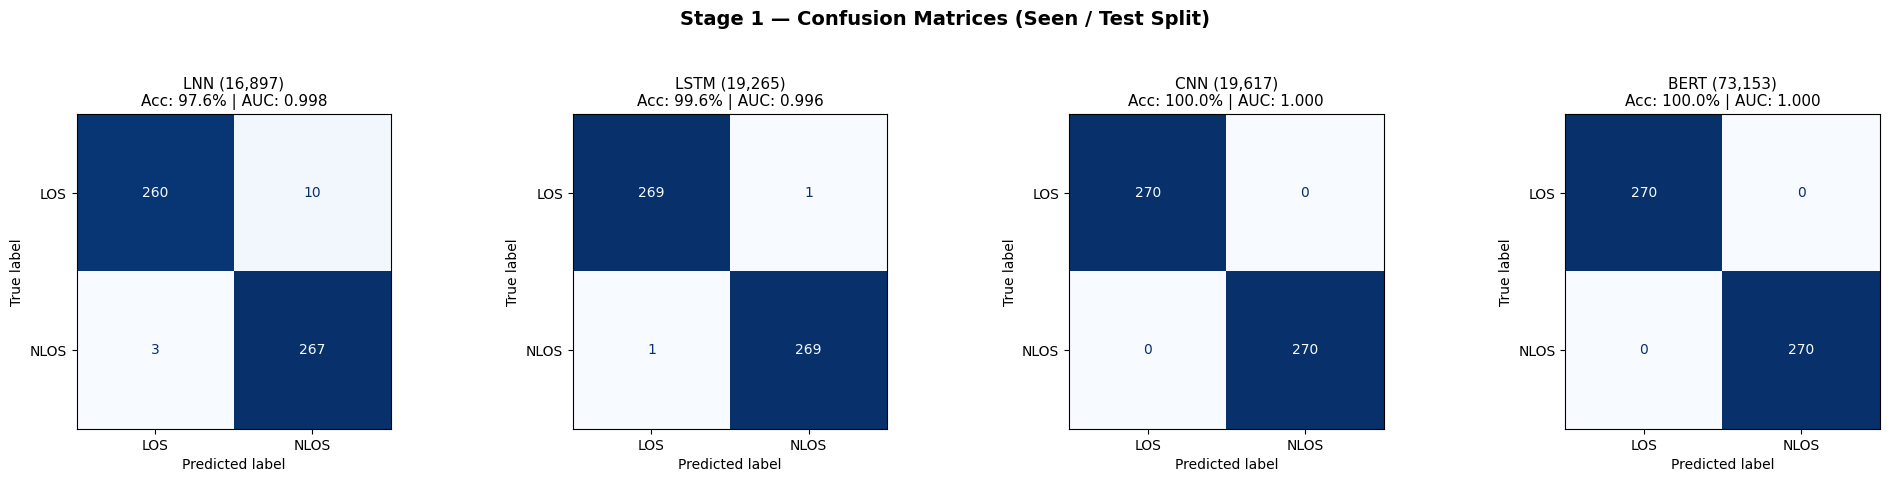

In [11]:
# ==========================================
# CONFUSION MATRICES — SEEN (TEST SPLIT)
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, name in enumerate(encoder_names):
    ax = axs[idx]
    r = results[name]
    disp = ConfusionMatrixDisplay(r['seen_cm'], display_labels=['LOS', 'NLOS'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name} ({r['n_params']:,})\nAcc: {100*r['seen_acc']:.1f}% | AUC: {r['seen_auc']:.3f}", fontsize=11)
plt.suptitle("Stage 1 — Confusion Matrices (Seen / Test Split)", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

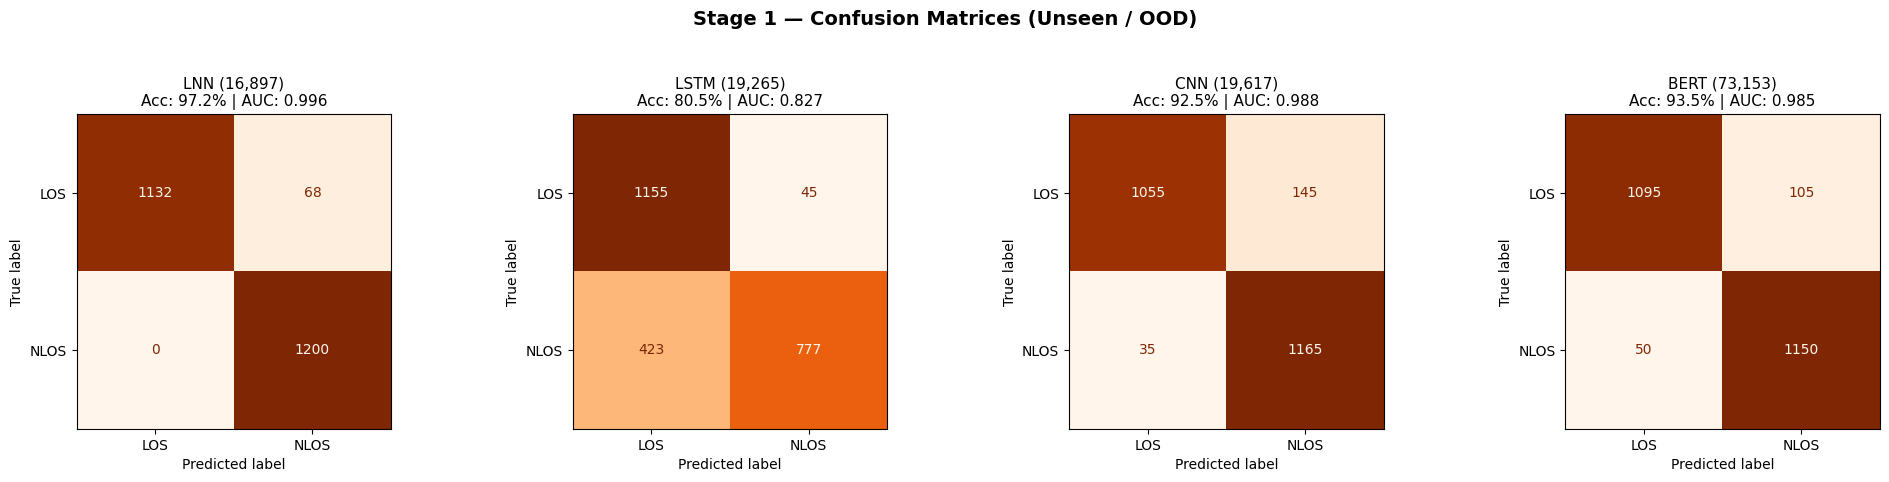

In [12]:
# ==========================================
# CONFUSION MATRICES — UNSEEN (OOD)
# ==========================================
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for idx, name in enumerate(encoder_names):
    ax = axs[idx]
    r = results[name]
    disp = ConfusionMatrixDisplay(r['unseen_cm'], display_labels=['LOS', 'NLOS'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f"{name} ({r['n_params']:,})\nAcc: {100*r['unseen_acc']:.1f}% | AUC: {r['unseen_auc']:.3f}", fontsize=11)
plt.suptitle("Stage 1 — Confusion Matrices (Unseen / OOD)", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 6. ROC Curves

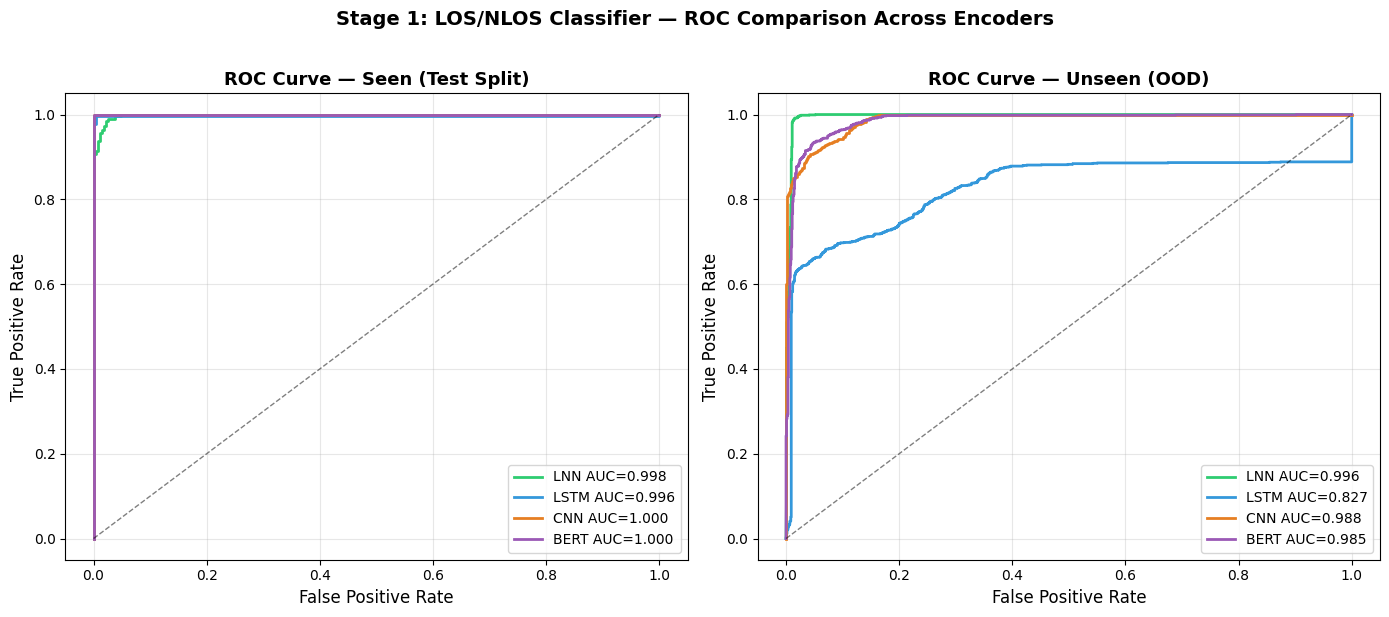

In [13]:
# ==========================================
# ROC CURVES — SEEN vs UNSEEN (side by side)
# ==========================================
colors = {'LNN': '#2ecc71', 'LSTM': '#3498db', 'CNN': '#e67e22', 'BERT': '#9b59b6'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Seen ROC
for name in encoder_names:
    r = results[name]
    ax1.plot(r['seen_fpr'], r['seen_tpr'], color=colors[name], lw=2,
             label=f"{name} AUC={r['seen_auc']:.3f}")
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve — Seen (Test Split)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Unseen ROC
for name in encoder_names:
    r = results[name]
    ax2.plot(r['unseen_fpr'], r['unseen_tpr'], color=colors[name], lw=2,
             label=f"{name} AUC={r['unseen_auc']:.3f}")
ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve — Unseen (OOD)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Stage 1: LOS/NLOS Classifier — ROC Comparison Across Encoders',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Precision-Recall Curves

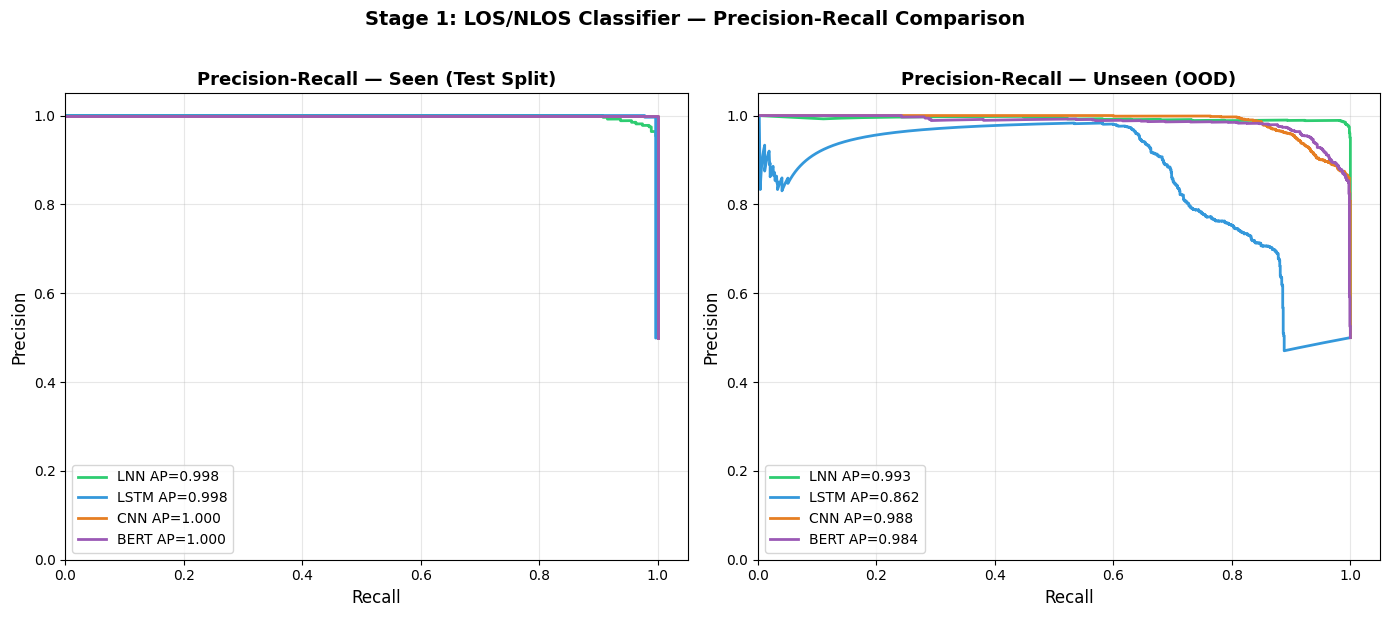

In [14]:
# ==========================================
# PRECISION-RECALL CURVES — SEEN vs UNSEEN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Seen PR
for name in encoder_names:
    r = results[name]
    ax1.plot(r['seen_rec_curve'], r['seen_prec_curve'], color=colors[name], lw=2,
             label=f"{name} AP={r['seen_ap']:.3f}")
ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall — Seen (Test Split)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1.05]); ax1.set_ylim([0, 1.05])

# Unseen PR
for name in encoder_names:
    r = results[name]
    ax2.plot(r['unseen_rec_curve'], r['unseen_prec_curve'], color=colors[name], lw=2,
             label=f"{name} AP={r['unseen_ap']:.3f}")
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall — Unseen (OOD)', fontsize=13, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1.05]); ax2.set_ylim([0, 1.05])

plt.suptitle('Stage 1: LOS/NLOS Classifier — Precision-Recall Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Bar Chart Comparisons

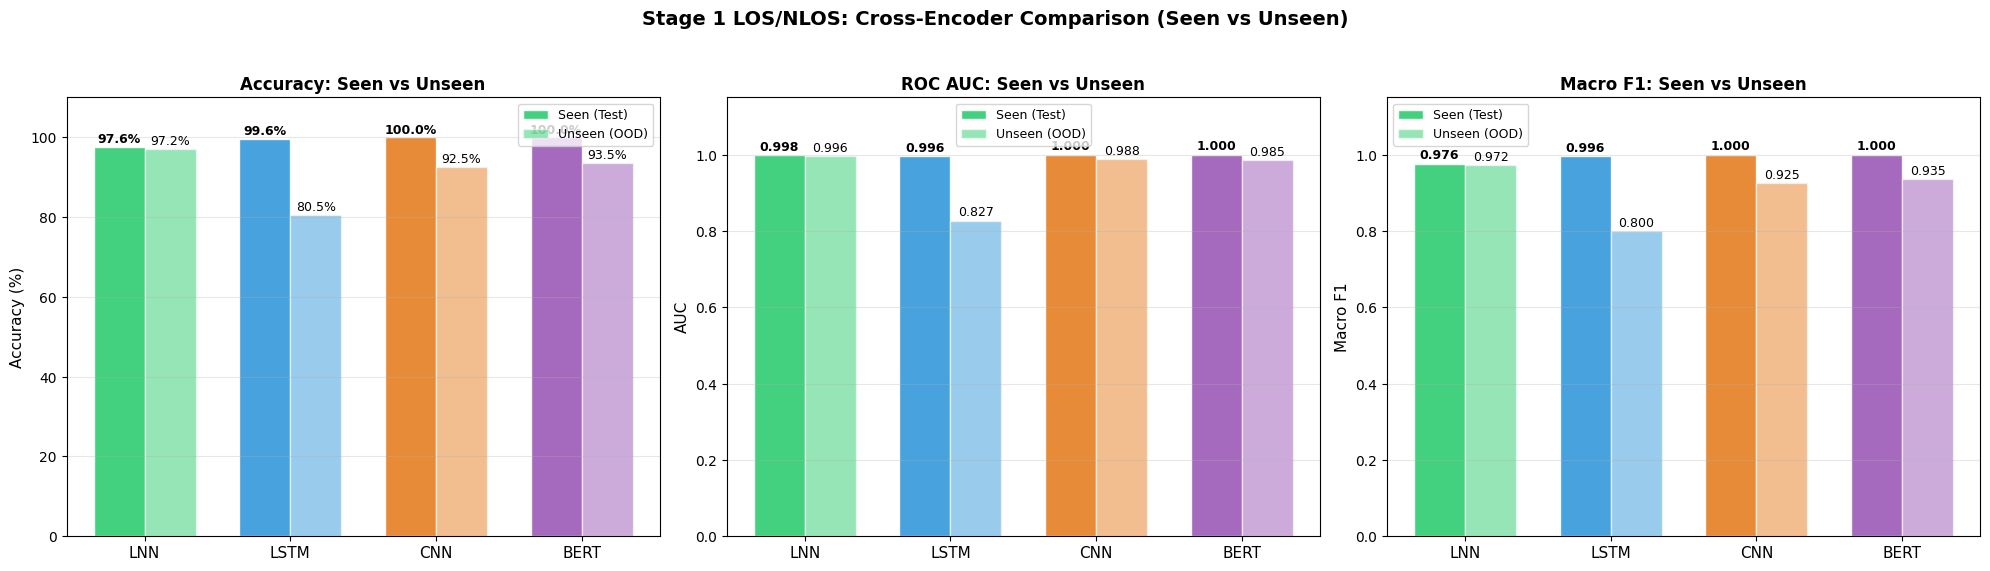

In [15]:
# ==========================================
# BAR CHARTS — ACCURACY, AUC, MACRO F1 (Seen vs Unseen)
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(20, 5.5))

x = np.arange(len(encoder_names))
w = 0.35
c_seen = [colors[n] for n in encoder_names]

# Plot 1: Accuracy
ax = axs[0]
seen_accs = [100*results[n]['seen_acc'] for n in encoder_names]
unseen_accs = [100*results[n]['unseen_acc'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_accs, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_accs, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(0, 110)

# Plot 2: AUC
ax = axs[1]
seen_aucs = [results[n]['seen_auc'] for n in encoder_names]
unseen_aucs = [results[n]['unseen_auc'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_aucs, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_aucs, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('ROC AUC: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(0, 1.15)

# Plot 3: Macro F1
ax = axs[2]
seen_f1m = [results[n]['seen_report']['macro avg']['f1-score'] for n in encoder_names]
unseen_f1m = [results[n]['unseen_report']['macro avg']['f1-score'] for n in encoder_names]
bars1 = ax.bar(x - w/2, seen_f1m, w, label='Seen (Test)', color=c_seen, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_f1m, w, label='Unseen (OOD)', color=c_seen, alpha=0.5, edgecolor='white')
for bar, val in zip(bars1, seen_f1m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, unseen_f1m):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(encoder_names, fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Macro F1: Seen vs Unseen', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(0, 1.15)

plt.suptitle('Stage 1 LOS/NLOS: Cross-Encoder Comparison (Seen vs Unseen)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 9. Full Classification Reports (Printable)

In [16]:
# ==========================================
# FULL CLASSIFICATION REPORTS — FOR COPY-PASTE TO REPORT
# ==========================================
for name in encoder_names:
    r = results[name]
    print(f"\n{'='*70}")
    print(f"{name} ({r['n_params']:,} params) — SEEN (Test Split)")
    print(f"{'='*70}")
    print(f"Accuracy: {100*r['seen_acc']:.2f}%")
    print(f"ROC AUC:  {r['seen_auc']:.4f}")
    print(f"Avg Precision (AP): {r['seen_ap']:.4f}")
    print()
    print(classification_report(y_test, r['seen_pred'],
                                 target_names=['LOS', 'NLOS']))
    print("Per-scenario accuracy:")
    for sc in unique_scenarios_seen:
        acc = r['seen_per_scenario'].get(sc, 0)
        print(f"  {sc:>16s}: {100*acc:.1f}%")

    print(f"\n{'-'*70}")
    print(f"{name} ({r['n_params']:,} params) — UNSEEN (OOD)")
    print(f"{'-'*70}")
    print(f"Accuracy: {100*r['unseen_acc']:.2f}%")
    print(f"ROC AUC:  {r['unseen_auc']:.4f}")
    print(f"Avg Precision (AP): {r['unseen_ap']:.4f}")
    print()
    print(classification_report(y_unseen, r['unseen_pred'],
                                 target_names=['LOS', 'NLOS']))
    print("Per-scenario accuracy:")
    for sc in unique_scenarios_unseen:
        acc = r['unseen_per_scenario'].get(sc, 0)
        print(f"  {sc:>16s}: {100*acc:.1f}%")


LNN (16,897 params) — SEEN (Test Split)
Accuracy: 97.59%
ROC AUC:  0.9985
Avg Precision (AP): 0.9985

              precision    recall  f1-score   support

         LOS       0.99      0.96      0.98       270
        NLOS       0.96      0.99      0.98       270

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540

Per-scenario accuracy:
       16.09m_nlos: 97.4%
       16.80m_nlos: 100.0%
         8.41m_los: 100.0%
         9.29m_los: 100.0%
        9.54m_nlos: 99.0%
         9.76m_los: 89.9%

----------------------------------------------------------------------
LNN (16,897 params) — UNSEEN (OOD)
----------------------------------------------------------------------
Accuracy: 97.17%
ROC AUC:  0.9957
Avg Precision (AP): 0.9929

              precision    recall  f1-score   support

         LOS       1.00      0.94      0.97      1200
        NLOS       0.95      1.00      

---
## 10. Per-Scenario Accuracy Bar Charts

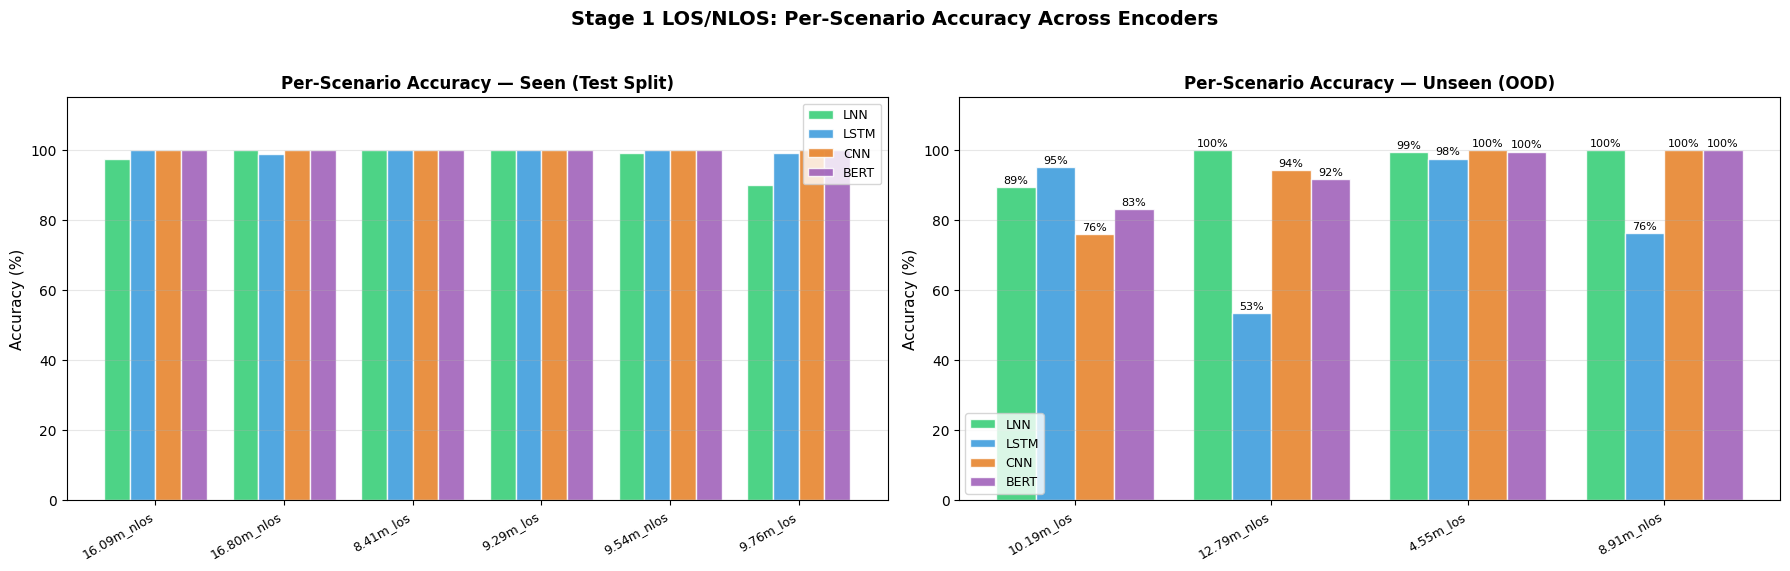

In [17]:
# ==========================================
# PER-SCENARIO ACCURACY — SEEN + UNSEEN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))

n_enc = len(encoder_names)
bw = 0.8 / n_enc

# Seen scenarios
n_sc = len(unique_scenarios_seen)
x_sc = np.arange(n_sc)
for idx, name in enumerate(encoder_names):
    accs = [100*results[name]['seen_per_scenario'].get(sc, 0) for sc in unique_scenarios_seen]
    offset = (idx - n_enc/2 + 0.5) * bw
    ax1.bar(x_sc + offset, accs, bw, label=name, color=colors[name], alpha=0.85, edgecolor='white')
ax1.set_xticks(x_sc)
ax1.set_xticklabels([s for s in unique_scenarios_seen], fontsize=9, rotation=30, ha='right')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Per-Scenario Accuracy — Seen (Test Split)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y'); ax1.set_ylim(0, 115)

# Unseen scenarios
n_sc_u = len(unique_scenarios_unseen)
x_sc_u = np.arange(n_sc_u)
for idx, name in enumerate(encoder_names):
    accs = [100*results[name]['unseen_per_scenario'].get(sc, 0) for sc in unique_scenarios_unseen]
    offset = (idx - n_enc/2 + 0.5) * bw
    bars = ax2.bar(x_sc_u + offset, accs, bw, label=name, color=colors[name], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, accs):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x_sc_u)
ax2.set_xticklabels([s for s in unique_scenarios_unseen], fontsize=9, rotation=30, ha='right')
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Per-Scenario Accuracy — Unseen (OOD)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y'); ax2.set_ylim(0, 115)

plt.suptitle('Stage 1 LOS/NLOS: Per-Scenario Accuracy Across Encoders',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 11. Prediction Confidence Distributions

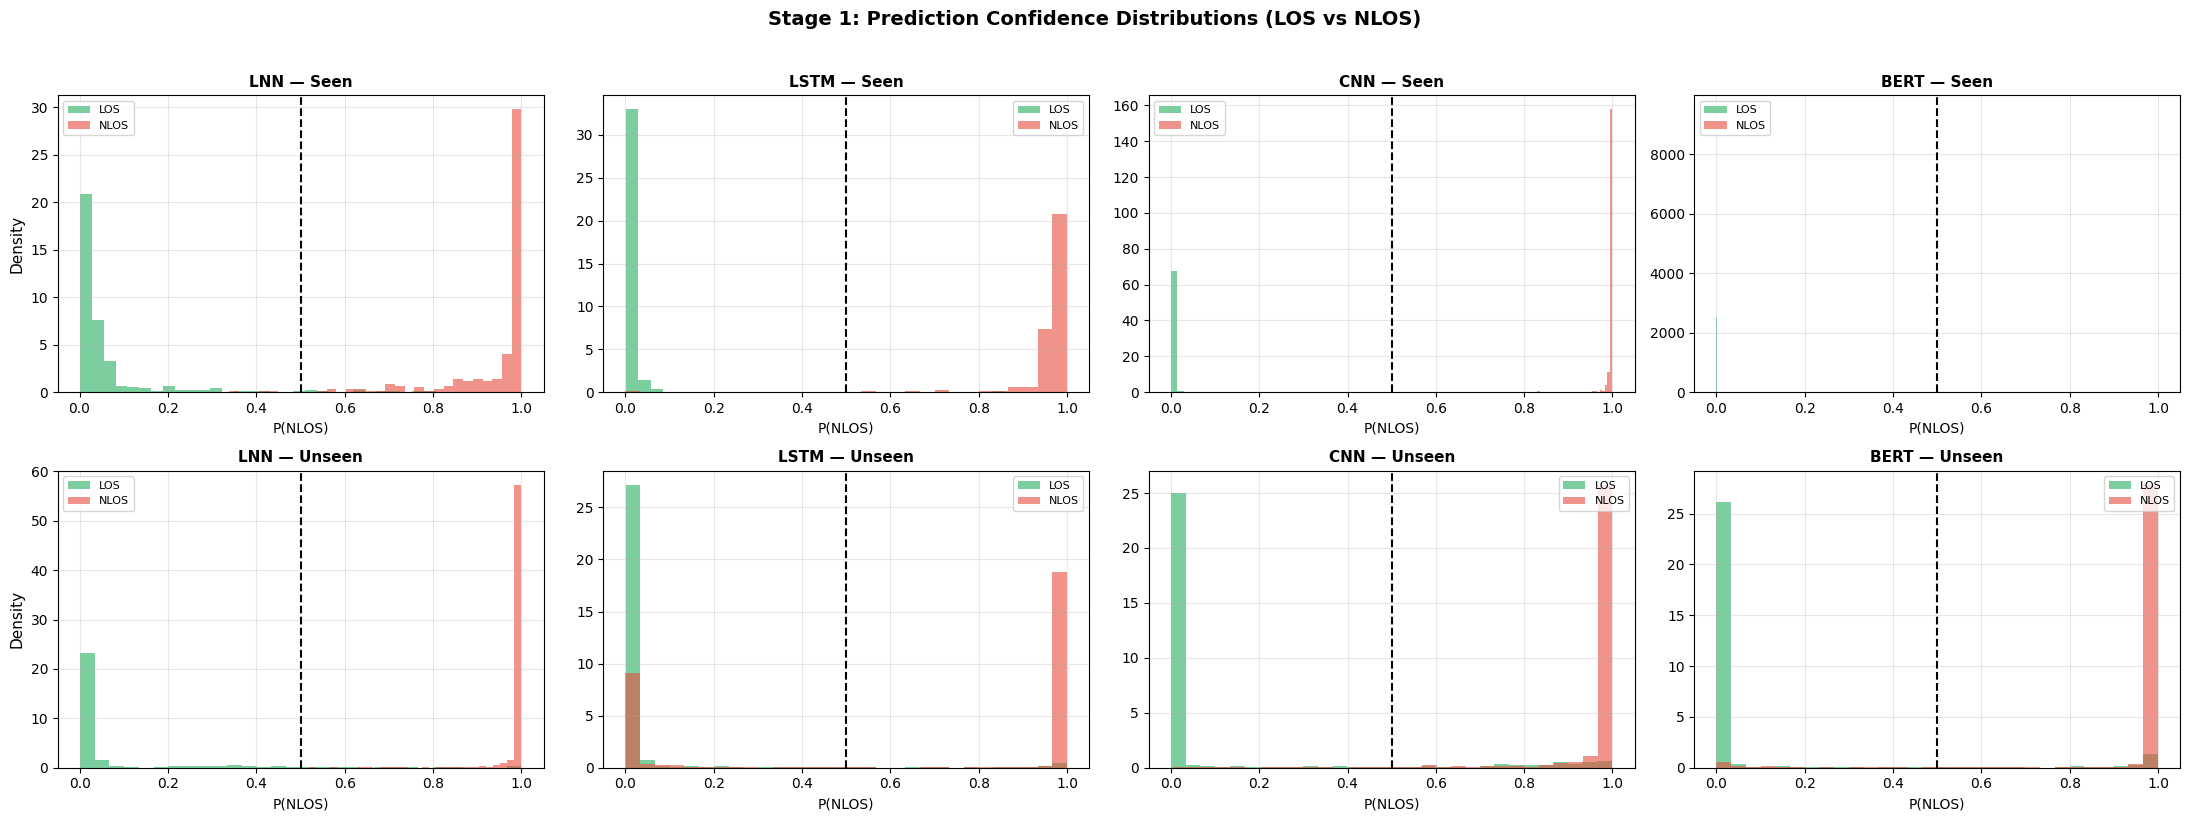

In [18]:
# ==========================================
# PREDICTION CONFIDENCE — SEEN + UNSEEN
# ==========================================
fig, axs = plt.subplots(2, 4, figsize=(22, 8))

for idx, name in enumerate(encoder_names):
    r = results[name]

    # Seen (top row)
    ax = axs[0, idx]
    ax.hist(r['seen_prob'][y_test == 0], bins=30, alpha=0.6, color='#27ae60',
            label='LOS', density=True)
    ax.hist(r['seen_prob'][y_test == 1], bins=30, alpha=0.6, color='#e74c3c',
            label='NLOS', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1.5)
    ax.set_title(f"{name} — Seen", fontsize=11, fontweight='bold')
    ax.set_xlabel('P(NLOS)'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Unseen (bottom row)
    ax = axs[1, idx]
    ax.hist(r['unseen_prob'][y_unseen == 0], bins=30, alpha=0.6, color='#27ae60',
            label='LOS', density=True)
    ax.hist(r['unseen_prob'][y_unseen == 1], bins=30, alpha=0.6, color='#e74c3c',
            label='NLOS', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1.5)
    ax.set_title(f"{name} — Unseen", fontsize=11, fontweight='bold')
    ax.set_xlabel('P(NLOS)'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axs[0, 0].set_ylabel('Density', fontsize=11)
axs[1, 0].set_ylabel('Density', fontsize=11)
plt.suptitle('Stage 1: Prediction Confidence Distributions (LOS vs NLOS)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Training & Validation Curves

Learning curves (train/val loss and accuracy over epochs) loaded from saved training history in each encoder's config `.pt` file.

**Note**: CNN uses a separate config format — history is loaded from `cnn/stage1_cnn_config.pt`. All 4 encoders must have `"history"` saved in their config files. Re-run LSTM and BERT training notebooks if history is missing.

LNN: loaded history (50 epochs)
LSTM: loaded history (33 epochs)
CNN: loaded history (14 epochs)
BERT: loaded history (17 epochs)


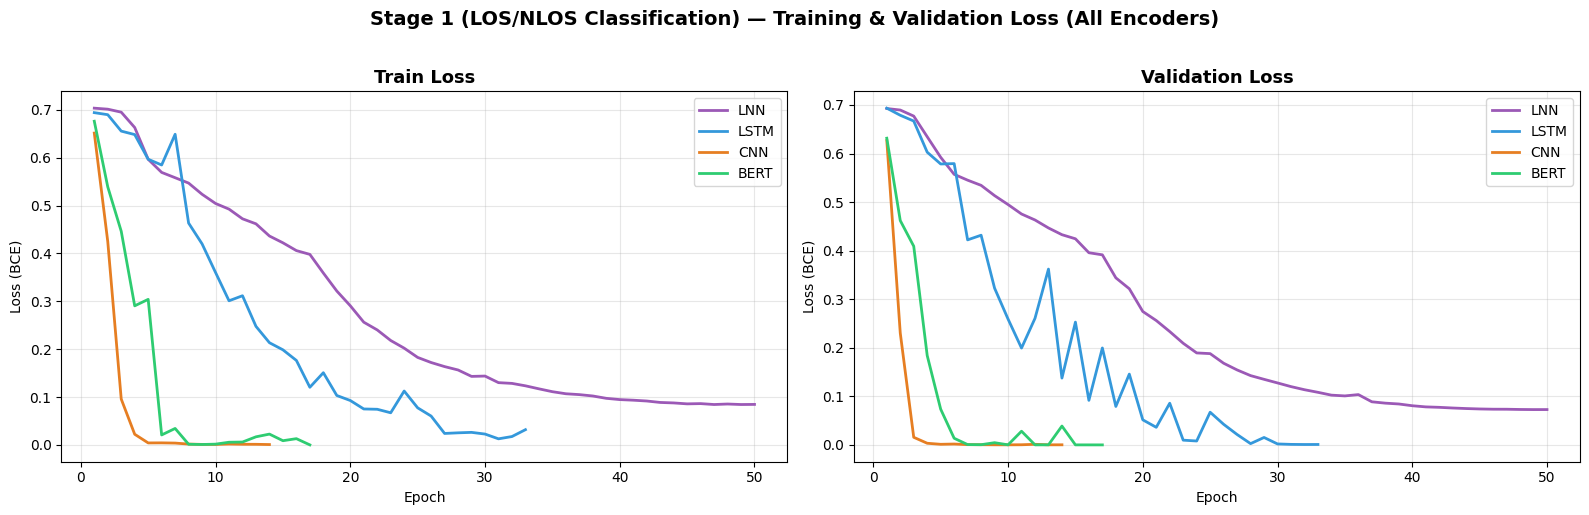

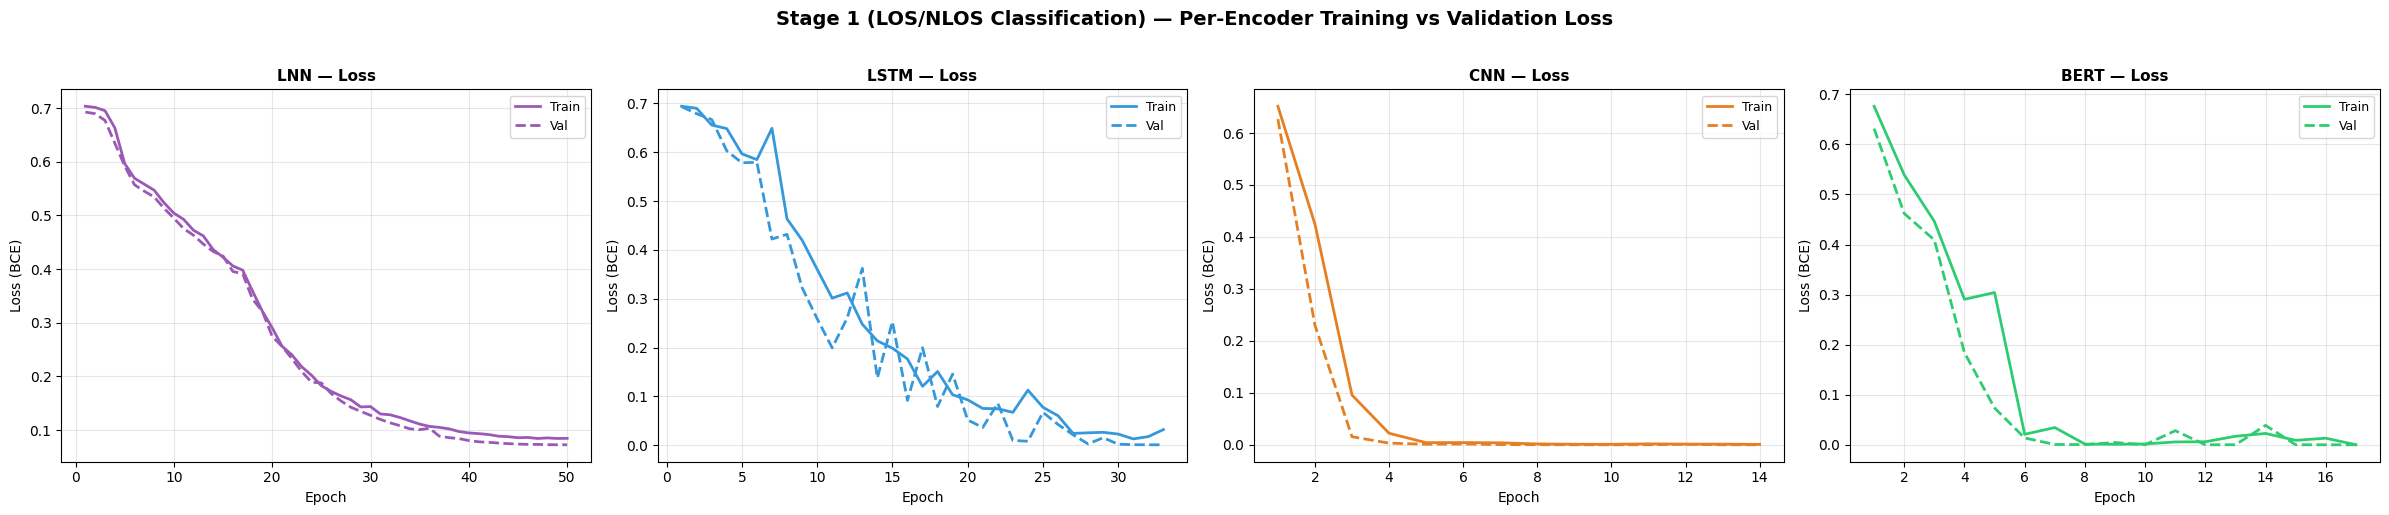


CONVERGENCE SUMMARY

LNN:
  Total epochs:     50
  Best val acc:     98.52% (epoch 48)
  Final train loss: 0.0847
  Final val loss:   0.0728

LSTM:
  Total epochs:     33
  Best val acc:     100.00% (epoch 23)
  Final train loss: 0.0320
  Final val loss:   0.0009

CNN:
  Total epochs:     14
  Best val acc:     100.00% (epoch 4)
  Final train loss: 0.0009
  Final val loss:   0.0002

BERT:
  Total epochs:     17
  Best val acc:     100.00% (epoch 7)
  Final train loss: 0.0002
  Final val loss:   0.0000


In [19]:
# ==========================================
# TRAINING & VALIDATION CURVES — ALL 4 ENCODERS
# ==========================================

# Load training history from config files
config_paths = {
    "LNN":  "lnn/stage1_pi_hlnn_no_fp_v3_config.pt",
    "LSTM": "lstm/stage1_lstm_config.pt",
    "CNN":  "cnn/stage1_cnn_config.pt",
    "BERT": "bert/stage1_bert_config.pt",
}

histories = {}
for name, path in config_paths.items():
    saved = torch.load(path, map_location="cpu", weights_only=False)
    if "history" in saved:
        histories[name] = saved["history"]
        n_epochs = len(saved["history"]["train_loss"])
        print(f"{name}: loaded history ({n_epochs} epochs)")
    else:
        print(f"{name}: NO history found in {path} — re-run training notebook to save history")

if not histories:
    print("\nNo training histories available. Re-run training notebooks with history saving enabled.")
else:
    encoder_colors = {"LNN": "#9b59b6", "LSTM": "#3498db", "CNN": "#e67e22", "BERT": "#2ecc71"}

    # --- OVERLAY LOSS CURVES (Train | Val side-by-side) ---
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    ax = axs[0]
    for name, hist in histories.items():
        epochs = range(1, len(hist["train_loss"]) + 1)
        ax.plot(epochs, hist["train_loss"], label=name, color=encoder_colors[name], lw=2)
    ax.set_title("Train Loss", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (BCE)")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    ax = axs[1]
    for name, hist in histories.items():
        epochs = range(1, len(hist["val_loss"]) + 1)
        ax.plot(epochs, hist["val_loss"], label=name, color=encoder_colors[name], lw=2)
    ax.set_title("Validation Loss", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (BCE)")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    plt.suptitle("Stage 1 (LOS/NLOS Classification) — Training & Validation Loss (All Encoders)",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # --- PER-ENCODER DETAIL (train vs val loss on same plot) ---
    n_enc = len(histories)
    fig, axs = plt.subplots(1, n_enc, figsize=(6 * n_enc, 5))
    if n_enc == 1:
        axs = [axs]

    for col, (name, hist) in enumerate(histories.items()):
        epochs = range(1, len(hist["train_loss"]) + 1)
        color = encoder_colors[name]

        ax = axs[col]
        ax.plot(epochs, hist["train_loss"], label='Train', color=color, lw=2)
        ax.plot(epochs, hist["val_loss"], label='Val', color=color, lw=2, ls='--')
        ax.set_title(f"{name} — Loss", fontsize=11, fontweight='bold')
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (BCE)")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle("Stage 1 (LOS/NLOS Classification) — Per-Encoder Training vs Validation Loss",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # --- CONVERGENCE SUMMARY ---
    print("\n" + "=" * 60)
    print("CONVERGENCE SUMMARY")
    print("=" * 60)
    for name, hist in histories.items():
        n_ep = len(hist["train_loss"])
        best_val_acc = max(hist["val_acc"]) * 100
        best_epoch = hist["val_acc"].index(max(hist["val_acc"])) + 1
        final_train_loss = hist["train_loss"][-1]
        final_val_loss = hist["val_loss"][-1]
        print(f"\n{name}:")
        print(f"  Total epochs:     {n_ep}")
        print(f"  Best val acc:     {best_val_acc:.2f}% (epoch {best_epoch})")
        print(f"  Final train loss: {final_train_loss:.4f}")
        print(f"  Final val loss:   {final_val_loss:.4f}")

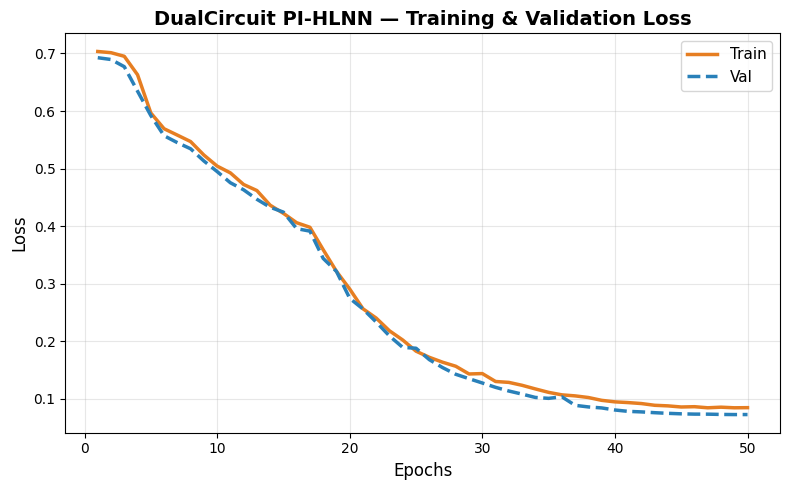

Total epochs: 50
Initial train loss: 0.7035
Final train loss:   0.0847
Initial val loss:   0.6926
Final val loss:     0.0728


In [23]:
# ==========================================
# LNN TRAIN & VAL LOSS CURVE (for report)
# ==========================================

lnn_config = torch.load("lnn/stage1_pi_hlnn_no_fp_v3_config.pt", map_location="cpu", weights_only=False)
lnn_hist = lnn_config["history"]

epochs = range(1, len(lnn_hist["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, lnn_hist["train_loss"], color='#E67E22', lw=2.5, label='Train')
ax.plot(epochs, lnn_hist["val_loss"], color='#2980B9', lw=2.5, label='Val', ls='--')
ax.set_title("DualCircuit PI-HLNN — Training & Validation Loss", fontsize=14, fontweight='bold')
ax.set_xlabel("Epochs", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total epochs: {len(lnn_hist['train_loss'])}")
print(f"Initial train loss: {lnn_hist['train_loss'][0]:.4f}")
print(f"Final train loss:   {lnn_hist['train_loss'][-1]:.4f}")
print(f"Initial val loss:   {lnn_hist['val_loss'][0]:.4f}")
print(f"Final val loss:     {lnn_hist['val_loss'][-1]:.4f}")

---
## Summary

This notebook contains all Stage 1 LOS/NLOS classifier metrics across all 4 encoder architectures.

**Sections for report reference:**
- Table 1: Overall metrics (Acc, AUC, AP, F1) for seen and unseen
- Table 2-3: Per-class precision/recall/F1
- Table 4: Per-scenario accuracy breakdown
- Table 5: Generalization gap
- Plots: Confusion matrices, ROC curves, PR curves, bar charts, confidence distributions